### Metropolis Hastings Algorithm

Cuando el resultado de la distribución posteriuor no genera una Full conditional distribution y el mestreo de Gibbs no se puede implementar. Existe una alternativa que es el Metropolis Hastings que es un MCMC y permite generar una algoritmo que sea producto de cualquier combinación de una prior y una posterior.

Esto significa que el algorítmo sigue un proceso similar al del muestreo de Gibbs. La dificultad que se desea resolver con la forma generica del Metropolis Hasting es lograr una convergencia en los resultados cuando la distribución posterior y le prior parten de distribuciones diferentes. En el muestreo de Gibbs se nombra la distribución de denisdad $f$ que es sobre la que una distribución instrumental que ahora se nombrará como $q$ y que es sobre la que se obtienen los resultados.

El algoritmo de Metropolis Hastings crear un métzodo en el que a partir de las simulaciones hay una probabilidad de aceptar el valor o rechazarlo. En la medida en que cada uno de los valores se acepta, esto empiezan a formar parte de un vector hasta que se completan todos lo valores.

El problema es crear un algoritmo que de forma óptima acepte y rechaze esos valores que contruyen la función de densidad obejtivo.

En este cuaderno se abordaran diferentes algoritmos de Metropolis Hastings en el que cada uno tiene una variación que se conentra en determinar la probabilidad de aceptar o rechazar un valor.

***Metropolis Hastings Algorithm con Dependencia***

El primero es el siguiente:

Dada una variables $x_{t}$:

1. Se genera $Y_{t} \sim q(y \mid x_{t})$
2. Luego $X_{t+1}$ puede tomar dos valores $Y_{t}$ con probabilidad $\rho(x_{t}, Y_{t})$
o $x_{t}$ con probabilidad $1- \rho(x_{t}, Y_{t})$.

Donde $\rho(x,y)= min \Big(\frac{f(y)}{f(x)}\frac{q(x\mid y)}{q(y \mid x)},1 \Big)$.

La distribución $q$ es la distribución instrumental y la probabilidad $\rho(x,y)$ es la probabilidad de aceptación del Metropolis Hasting y además este algoritmo depende del estado en el que se encuentra la variable en la cadena de markov.


El objetivo del algoritmo  es explorar  la distribución de densidad $f$ de acuerdo con su probabilidad y que converge a la distribución $f$ (conocida como la distribución objetivo) dependiendo de la  propuesta $q$ que puede variar en la medida en que esta se modifique. Esto solo se logra cuando la función de densidad es estacionaria y por lo tanto se cumple con la siguiente condición:

$$f(x)K(y\mid x)=f(y)K(x\mid y)$$

Donde $K(x\mid y)$ es el kernel (nucleo) de la distribución estacionaria de $f$ que estabelce una restricción llamada irreducibilidad en la que dentro de la cadena de markov este kernel permitelos movimientos libres entre los estados. De esta forma una función se puede obtener como:

$$\int K(x,y)f(x)df=f(y)$$

En este aspecto, el proceso de aceptar o rechazo del resultado del algoritmo depende directamente del componente estacionario que permite la creación de las cadeas de Markov. Esto es más difícil de obtener cuando la distribución prior y posterior son diferentes.

Las propiedades del Metropolis Hasting son las siguientes:

1. No es unadistribución i.i.d.
2. Si no se cumple con el valor de $Y_{t}$ el agoritmo repetira el paso 2 hasta encontrar una valor que permita a la variable $x$ pasar del estado $t$ al $t+1$.


Tasas de aceptación:

Es importante monitorear la tasa de aceptación (la fracción de sorteos candidatos que son aceptados) del Metropolis-Hastings.

Si la tasa de aceptación es demasiado alta, es probable que la cadena no se mezcle bien (no se mueva por el espacio de parámetros lo suficientemente rápido).
Si su tasa de aceptación es demasiado baja, su algoritmo es demasiado ineficiente
(rechazando demasiados empates de candidatos).

Un ejemplo de algoritmo de Metropolis Hasting es el de distribución beta en el que se utiliza un distribución uniforme para iniciar la cadena de Markov.


In [13]:
import numpy as np
from scipy.stats import beta

#### Metropolis Hastings Algorithm
# Initial values
a=2.7
b=6.3
c=2.669
Nsim=50000
## X vector using one value of uniform distribution with lengt Nsim
## set seed to get same results every time
np.random.seed(0)
x=np.random.uniform(0,1,1)
### create a vector of Nsim vavlues with the same value of x
X=np.repeat(x,Nsim)

for i in range(2,Nsim):
    #### Metropolis Hastings Algorithm
    #### generate a random number
    Y=np.random.uniform(0,1,1)
    #### create a ratio with density beta distribution 
    rho=beta.pdf(Y,a,b)/beta.pdf(X[i-1],a,b) ## la tasa de aceptación depende del valor inicial y del estado en el que se encuenzta en la cadena de markov
    X[i]=X[i-1]+(Y-X[i-1])*(np.random.uniform(0,1,1)<rho) 

  



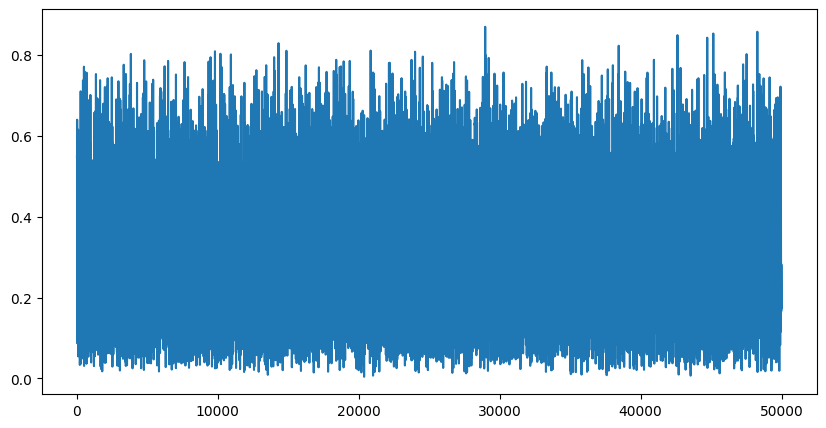

In [14]:
### PLot the results from 4500 to 5000
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(X)

In [7]:
### Kolgomorv test for beta distribution two sides
from scipy.stats import kstest
kstest(X,"beta",args=(a,b),alternative='two-sided') # p-value < 0.05
mean=np.mean(X) # 0.5
var=np.var(X) # 0.5¥
## Create a data frame with the results of mean and var and kstest
import pandas as pd
df=pd.DataFrame({"mean":mean,"var":var,"kstest":kstest(X,"beta",args=(a,b),alternative='two-sided')})

df

,mean,var,kstest
0,0.29981,0.020914,0.004655
1,0.29981,0.020914,0.227966


/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_22422/1403007942.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X, hist=True, kde=True,
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_22422/1403007942.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figur

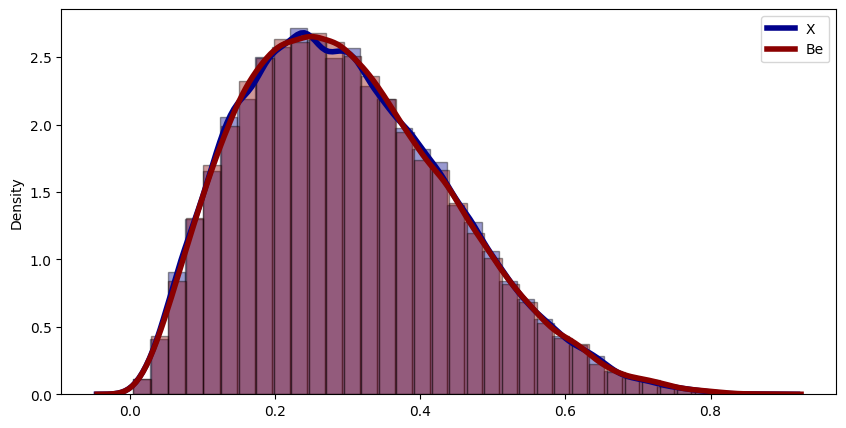

In [8]:
## Create a random vector of beta distribution with a and b an length of Nsim
import seaborn as sns
np.random.seed(0)
Be=np.random.beta(a,b,Nsim)
#### Histogram of the results X and Be in different figures 
plt.figure(figsize=(10,5))
sns.distplot(X, hist=True, kde=True, 
             bins=int(180/5), color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(Be, hist=True, kde=True,
                bins=int(180/5), color = 'darkred',
                hist_kws={'edgecolor':'black'},
                kde_kws={'linewidth': 4})
## legend
plt.legend(['X','Be'])
                










## create

En este ejemplo se observa como el algoritmo es capaz de reproducir una ditribución beta, en donde el promedio teórico es 0.301 y la varianza teórica es 0.0205

***Metropolis Hastings Algorithm Independiente***

Un segundo algoritmo de Metropolis Hasting que no depende del estado en el que se encuentra la variable en la cadena de markov es decir $q(y\mid x) =g(y)$ se desarrolla de la siguiente forma:

Dado $X_{t}$. 

1. Se genera $Y_{t}\sim g(y)$.
2. Luego $X_{t+1}$ puede tomar dos valores $Y_{t}$ con probabilidad $min\Big(\frac{f(Y_{t}g(x_{t})}{f(x_{t})g(Y_{t})},1\Big)$
o $x_{t}$ de otra forma.






In [15]:
#### Create a a Metropolis Hastings Algorithm for gamma distribution for 
# Calculate the mean of a gamma G(4.3,6.2) random variable using
# Gamma(4,7)
from scipy.stats import gamma
np.random.seed(0)
X=np.zeros(Nsim)
rho=np.zeros(Nsim)
g47=np.random.gamma(4,1/7,Nsim)
X[0]=np.random.gamma(4.3,1/6.2,1)
for i in range(1,Nsim):
    rho[i]=(gamma.pdf(X[i-1],4,1/7)*gamma.pdf(g47[i],4.3,1/6.2))/(gamma.pdf(g47[i],4,1/7)*gamma.pdf(X[i-1],4.3,1/6.2))
    X[i]=X[i-1]+(g47[i]-X[i-1])*(np.random.uniform(0,1,1)<rho[i])

/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_22422/2236818288.py:11: RuntimeWarning: invalid value encountered in scalar divide
  rho[i]=(gamma.pdf(X[i-1],4,1/7)*gamma.pdf(g47[i],4.3,1/6.2))/(gamma.pdf(g47[i],4,1/7)*gamma.pdf(X[i-1],4.3,1/6.2))


/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_22422/3464345183.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X, hist=True, kde=True,
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_22422/3464345183.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure

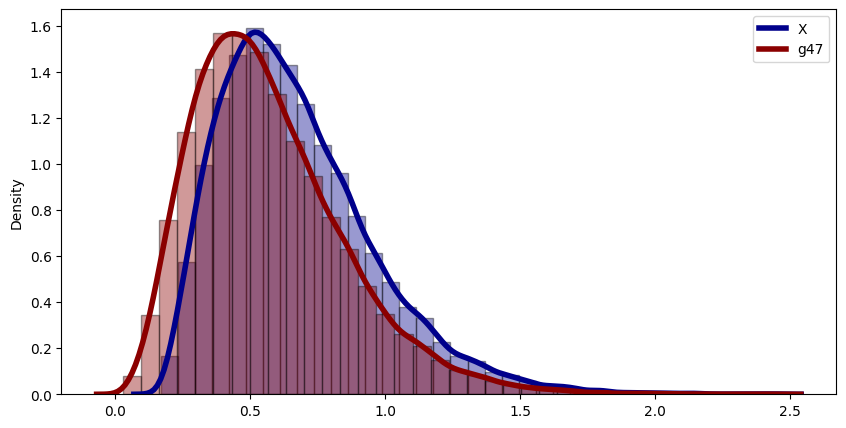

In [16]:
### Plot histogram of the results add curve density of the results

plt.figure(figsize=(10,5))
sns.distplot(X, hist=True, kde=True, 
             bins=int(180/5), color = 'darkblue', 
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
sns.distplot(g47, hist=True, kde=True,
                bins=int(180/5), color = 'darkred',
                hist_kws={'edgecolor':'black'},
                kde_kws={'linewidth': 4})
## legend
plt.legend(['X','g47'])
                








Con este ejemplo se puede ver como empatan ambas distribuciones cuando el cambio en los estados en independiente. La dificultad en la implementación en el algoritmo se basa en escoger correctamente el proceso. Por ejemplo, estos  dos casos se diferencian en la relación de los estados que en el procesos de Markov. Mientras que en el primero no se iteró sobre el valor de análisis, en el segundo se asumió una mayor ignorancia sobre el proceso y por lo tanto se generó un vector aleatorio con diferentes puntos que finalmente dieron resultado a la distribución azul que se ve en la gráfica. 




***Metropolis Hastings Algorithm con caminatas aleatorias***

Usualmente se utiliza una distribución uniforme para iniciar la cadena de Markov. Esto es porque como se ha mencionado anteriormente esta distribución permite describir la ignorancia total sobre los procesos o cualquier problema que deba resolverse a través de la estimación de parámetros. Dado que la cadena de Markov es un proceso que avanza entre estados,  la caminanta aleatoria es una forma de iniciar la cadena de Markov manteniendo la ignorancia en el proceso. El ejemplo más conocido porque el que se conoce este algoritmo, lo realizo Hastings en 1979. Se trata de estimar los parámetros de una distribución normmal partiendo de la generación de una camina aleatoria para lo estados de la cadena de Markov.


Un enfoque más natural para la construcción práctica de una propuesta de Metropolis-Hastings es, por tanto, tener en cuenta el valor previamente simulado para generar el siguiente valor; es decir, considerar una exploración local de la vecindad del valor actual de la cadena de Markov.

Por lo tanto el valor actual depende del estado en la cadena más un error:

$$ Y_{t}=x_{t}+\epsilon_{t}$$

Donde $Y_{t}\sim U(X_{t}-\delta,X_{t}+\delta)$ o $Y_{t}\sim N(X_{t},\tau^2)$


Dado $x_{t}$.

1. Se genera $Y_{t}\sim g(y-x_{t})$ para $g(y\mid x)$.
2. Luego $X_{t+1}$ puede tomar dos valores $Y_{t}$ con probabilidad $min(1, f(Y_{t})/f(x_{t}))$
    o $x_{t}$ de otra forma.


In [17]:
#### Metropolis Hastings Algorithm with random walk
# Initial values
np.random.seed(123456)
sigma=1
X=np.zeros(Nsim)
Y=np.zeros(Nsim)
## Create a random walk with mean 0 and variance 1
for i in range(Nsim):
    X[i]=X[i-1]+np.random.normal(0,sigma,1) ## initial values
    ratio=Y[i]/X[i] ## ratio
    if ratio>1:
        Y[i]=X[i]
    else:
        Y[i]=X[i-1]

/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_22422/1818963410.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Y, hist=True, kde=True)
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Density'>

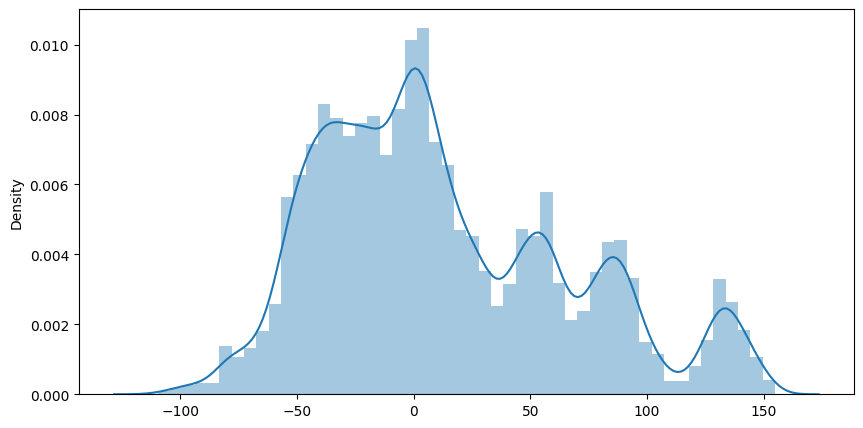

In [18]:
### plot a histrogram of the results
plt.figure(figsize=(10,5))
sns.distplot(Y, hist=True, kde=True)

In [19]:
for i in range(Nsim):
    Y[i]=X[i-1]+np.random.normal(0,sigma,1) ## initial values

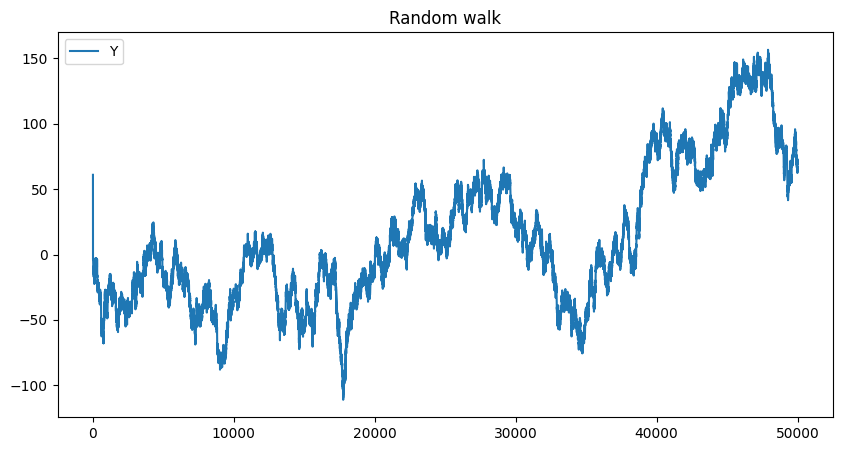

In [20]:
### plot the results with title and legend
plt.figure(figsize=(10,5))  
plt.plot(Y)
plt.title('Random walk')
plt.legend(['Y'])


El ejemplo anterior muestra como el algoritmo genera la valoración a partir de una caminata aleatoria que se puede observar en la última figura. Esta distribución tiende a ser simétrica, pero no lo suficiente para acercarse a una distribución normal. Con algunos ajustes y usandola en modelos multivariados de regresión lineal, este metodología servirá para la estimación de los parámetros de un modelo de regresión.

#### Caso de Estudio Riesgo Operativo.


Una fabrica industrial de autopartes de automoviles ha registrado un aumento en el costo variable de sus productos, a causa de los posibles accidentes de tránsito por la baja visibilidad del panorámico del carro. Este aumento se argumenta porque de acuerdo a los reportes, en momentos de lluvia el agua no logra deslizarse lo suficiente y bloquea la visibilidad. Por este motivo, la emprese debe comprar una nueva lente de visión para los vehículos que ayude a que el agua de la lluvia se deslize sin causar complicaciones. Sin embargo, para poder adaptar el producto al 100%, la empresa necesita un tiempo aproximado de dos años y mientras tanto debe producir los nuevos parabrisas con la nueva lente, pero con la posibilidad de que algunos de ellos salgan defectuosos y deban ser descartados.

El problema de esta fábrica, es que es una empresa pequeña y este incremento de los costos ha generando una disminución en el margen de ventas. Aunque el gerente de la empresa ha intentado obtener capital para acelerar el proceso de adaptación de las maquinas, no puede parar la producción y debe responder a los nuevos requerimientos de sus clientes, aunque esto signifique  tener perdidas en un tiempo derteminado por cuenta del entrenamiento del personal y las posibles fallas que se generen mientras se adaptan las maquinas. 

Después de una reunión con la junta directiva de la empresa, se determinó que el gerente tiene 8 meses para encontrar el capital necesario para la adaptación de las maquinas y evitar así la quiebra de la empresa. Pues esta no tiene los recursos necesarios para sobrevivir a los dos años. Mientras tanto la empresa debe evitar a toda costa producir parabrisas defectuosos que aumenten los costos para minimizar el riesgo de quiebra de la empresa.

***Puntos importantes***

1. Hay un horizonte de tiempo definido 8 meses.
2. Un incremento acelerado de productos defectuosos genera una quiebra.
3. No se conoce como será la nueva dinámica de producción y por lo tanto no hay un estimado del número de articulos defectuosos.

El costo de producir un parabrisas es de 3000 dólares que aumentará en un 40% con el nuevo lente.
La producción mensual de parabrisas es de 600 unidades.
Actualmente el 3% de la producción es defectuosa.

Se hicieron diez pruebas con el nuevo producto y la probabilidad de que las piezas salieran defectuosas fue del 30% con un error de 10%.

***Objetivo***


Estimar las posibles perdidas generadas por un evento que es extremo es decir que tiene un baja probabilidad de ocurrencia y que puede ocasionar grandes perdidas.

Se va a estimar una medida de riesgo operativo para la empresa. Esta se conoce como valor en riesgo.

El valor en riesgo mide la máxima perdida que puede alcanzar una empresa en un período de tiempo dado. En términos estadísticos es el percentil 5, que dependiendo de la distribución se puede ubicar en la cola derecha o izquierda y debe estimar la máxima perdida esperada.


La estimación del var es:


$$VaR=I*D_{95}*sd*\sqrt(t)$$

Donde $I$ es un valor numérico en términos monetarios, $sd$ la desviación estándar y $t$ el tiempo.

La distribución del valor en riesgo en el riesgo operacional es beta. 


La ecuación es:


$$ f(Y_{t})/f(x_{t})= \frac{likelihood(Y) \times prior(Y)}{likelihood(x)\times prior(x)}$$

En este caso se busca obtener el metropolitan hastings a partir de la relación entre la función likelihood que es la distribución binomial y la prior que es la distribución beta. 

Antes de mostrar el resultado, se presenta un ejemplo práctico del Valor en Riesgo en riesgo operativo.

/Users/andresmartinez/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


Text(0.7508103285038694, 0.5, 'VaR')

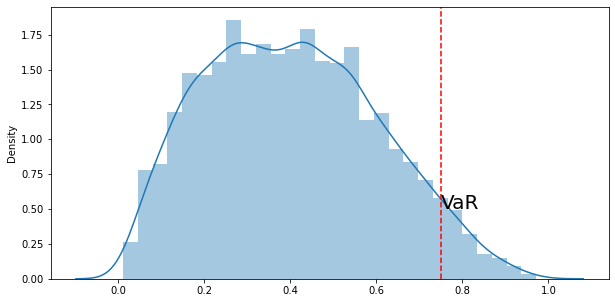

In [76]:
#### create a plot of a beta distribution
# Initial values
np.random.seed(123456)
x=np.random.beta(2,3,Nsim)
## plot the distribution
plt.figure(figsize=(10,5))
sns.distplot(x, hist=True, kde=True)
### vertical line in percentil 95
plt.axvline(x=np.percentile(x,95),color='r',linestyle='--')
### Insert a text in the vertical line VaR with font size 20
plt.text(np.percentile(x,95),0.5,'VaR',fontsize=20)



In [77]:
### Compute the VaR I=60000 and t=8 meses

var=6/(6*25)

VaR= 60000*beta.ppf(np.percentile(x,95),2,3)*np.sqrt(var)*np.sqrt(8)

VaR



18473.31349401611

En esta gráfica se observa el valor en riesgo usando una distribución beta. Esta es se utiliza para riesgos operacionales. Usando la ecuación sobre el VaR se observa que en un tiempo de o meses con una inversión de 60000, la máxima perdida esperada es de 18473. En este caso la desviación estándar se obtiene usando la ecuación de varianza de la distribución beta. Para este ejemplo los valores 2 y 3 que generaron la simulación se asignaron de forma arbitraria. 

El objetivo es hacer esta misma medición usando el algoritmo Metropolitan Hastings y obtener un VaR estimado para determinar la máxima perdida que puede llegar a tener la empresa.



In [74]:
#### Generación del metropolitan hastings
# Initial values
np.random.seed(123456)
from scipy.stats import binom 
### Likelihood function
def likelihood(x,n,p):
    return binom.pmf(x,n,p)
### prior function
def prior(x,a,b):
    return beta.pdf(x,a,b)

        
err=0.1
a=1
b=1
p=0.3
### Initial values
X=np.zeros(Nsim)
rho=np.zeros(Nsim)
b103= np.random.binomial(10,0.3,Nsim)


for i in range(Nsim):
    p=np.random.uniform(0,1,1)
    rho[i]=min(1,(likelihood(3,10,p)*prior(10,a,b))/(likelihood(b103[i],10,0.3)*prior(b103[i],a,b)))
    X[i]=b103[i-1]+(p-b103[i-1])*(np.random.uniform(0,1,1)<rho[i]) 





<ipython-input-74-3b9822b94f0e>:25: RuntimeWarning: invalid value encountered in true_divide
  rho[i]=min(1,(likelihood(3,10,p)*prior(10,a,b))/(likelihood(b103[i],10,0.3)*prior(b103[i],a,b)))


/Users/andresmartinez/opt/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


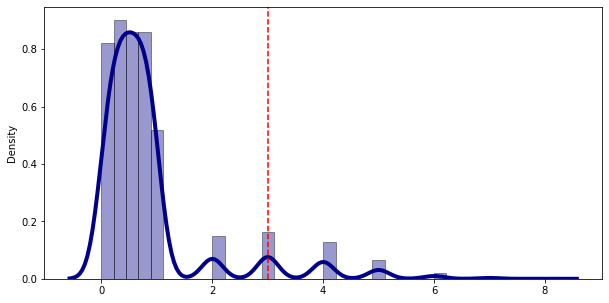

In [75]:
### plot the results
plt.figure(figsize=(10,5))
sns.distplot(X, hist=True, kde=True,
                bins=int(180/5), color = 'darkblue',
                hist_kws={'edgecolor':'black'},
                kde_kws={'linewidth': 4})
### vertical line with percentil 95   
plt.axvline(x=np.percentile(X,95),color='r',linestyle='--')             

In [85]:
Inversion=600*3000*1.4
BetaVar=1-beta.pdf(np.percentile(X,95),4,8)### Beta posterior distribution
var=np.var(X)
VaR=Inversion*BetaVar*np.sqrt(var)*np.sqrt(8)
VaR

1162074.4781782953

In [88]:
unid=(VaR/Inversion)*(600*8)
unid

2213.475196530086

De acuerdo al resultado anterior, se observa que la máxima perdida esperada en ocho meses es de $\$1162074$. Lo que significa que en términos de unidades producidas, la empresa no puede tener más de 2213 unidades defectuosas en 8 meses.



### Conclusión


En esta sección se presentó el algoritmo más importante de estadística bayesiana. Con el se pueden resolver diferentes combinaciones de distribuciones. En este módulo se abordaron tres metodologías:

1. Dependiente de la cadena de Markov.
2. Independiente de la cadena de Markov.
3. Usando caminantas aleatorias.

El siguiente paso es abordar modelos de regresión en el que el muestreo de gibbs y el algoritmo de Metropolis-Hastings, serviran para implementar los resultados de las diferentes combinaciones de las distribuciones prior y posterior. Lo anterior para poder estimar los coeficientes de la regresión.